# Slug collider

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/slug-collider/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/slug-collider/demo.ipynb)

**A slugifier returns a string. It cannot return the fact that two different titles just landed on the same one.**

`slugify("Node.js at scale")` and `slugify("NodeJS at scale")` both return `nodejs-at-scale`. Neither call
is wrong. Neither raises. The second post gets `nodejs-at-scale-2`, or overwrites the first, or fails an
insert at 2am during a bulk import - depending on code nobody wrote deliberately.

This notebook walks through what a slug function loses, using 44 ordinary blog titles. Nothing here is
adversarial and nothing is invalid; every line is a headline somebody would ship.

**Contents**

1. The fold is not accent-stripping
2. `lower()` versus `casefold()` - one line decides whether two titles collide
3. Two byte strings, one text, two URLs
4. The punctuation *is* the title
5. One Japanese title, seven published algorithms
6. The corpus audit and its three-valued verdict
7. The failure a `UNIQUE` index cannot catch
8. Shrinking the column adds collisions
9. The URL is a function of import order
10. Try your own

## Setup

`slug.py` is standard library only - `unicodedata`, `re`, `dataclasses`, `enum`. If you are on Colab or
Binder, the cell below pulls it from the repo; locally it is already next to this notebook.

In [1]:
from __future__ import annotations

import os
import urllib.request

if not os.path.exists("slug.py"):
    url = ("https://raw.githubusercontent.com/phoebefu6/phoebe-the-builder/"
           "main/automation-suite/slug-collider/slug.py")
    urllib.request.urlretrieve(url, "slug.py")

import unicodedata

import slug as S

print(f"{len(S.CORPUS)} titles, {len(S.PROFILES)} slug algorithms")
for name, p in S.PROFILES.items():
    print(f"  {name:22} {p.origin}")

44 titles, 7 slug algorithms
  django_ascii           Django slugify() default
  django_unicode         Django slugify(allow_unicode=True)
  naive_regex            hand-rolled [^a-z0-9]+
  casefold_ascii         django_ascii, casefold first
  rails_parameterize     Rails String#parameterize
  wordpress              WordPress sanitize_title_with_dashes
  github_anchor          GitHub heading anchors


## 1. The fold is not accent-stripping

Django's `slugify()` normalises **NFKD**, then drops every byte that is not ASCII. The usual explanation is
"it strips accents". That is not what it does.

NFKD decomposes a *composed* letter into a base character plus a combining mark, so `é` becomes `e` + U+0301
and the `e` survives the ASCII filter. A letter with **no decomposition** - `ß`, `ø`, `æ`, `Ł`, `þ`, `đ` -
has nothing to fall back to. It is deleted outright.

In [2]:
print(f"{'title':16} {'NFKD':26} {'slug':16} {'deleted'}")
print("-" * 72)
for t in ("café", "Ångström", "Straße", "Łódź", "Søren", "Encyclopædia", "Ærø"):
    nfkd = unicodedata.normalize("NFKD", t)
    lost = "".join(ch for ch in nfkd
                   if ord(ch) > 127 and not unicodedata.combining(ch))
    print(f"{t:16} {nfkd!r:26} {S.django_ascii(t):16} {lost or '-'}")

title            NFKD                       slug             deleted
------------------------------------------------------------------------
café             'café'                    cafe             -
Ångström         'Ångström'               angstrom         -
Straße           'Straße'                   strae            ß
Łódź             'Łódź'                   odz              Ł
Søren            'Søren'                    sren             ø
Encyclopædia     'Encyclopædia'             encyclopdia      æ
Ærø              'Ærø'                      r                Æø


`Straße` becomes `strae`. `Łódź` becomes `odz`. `Søren` becomes `sren`.

These are not edge cases in the sense of being rare - they are the ordinary spelling of ordinary words in
German, Polish and Danish. And `odz` is a real collision risk the moment the same blog publishes anything
whose title starts with those three letters.

In [3]:
a = "Łódź: our new datacentre"
b = "Odz - a naming retrospective"
for t in (a, b):
    print(f"{t:32} -> /{S.django_ascii(t)}")
print(f"\nboth begin /odz: {S.django_ascii(a)[:3] == S.django_ascii(b)[:3]}")

Łódź: our new datacentre         -> /odz-our-new-datacentre
Odz - a naming retrospective     -> /odz-a-naming-retrospective

both begin /odz: True


## 2. `lower()` versus `casefold()`

`str.lower()` is a 1:1 mapping. `str.casefold()` applies the full Unicode case-folding table, which expands
`ß` to `ss` and the `ﬁ` ligature to `fi`.

So *where you put the lowercasing step* decides whether `ß` survives the ASCII filter as `ss` or gets deleted.
Same characters, same steps, different order, different URL - and it decides whether two titles collide.

In [4]:
print(f"{'title':22} {'lower() first':16} {'casefold() first':16}")
print("-" * 60)
for t in ("Straße", "STRASSE", "Weiß", "ﬁle handles"):
    print(f"{t:22} {S.django_ascii(t):16} {S.casefold_ascii(t):16}")

pair = ["Straße oder Strasse", "STRASSE ODER STRASSE"]
print()
for name in ("django_ascii", "casefold_ascii"):
    got = sorted(set(S.audit(pair, name).slugs.values()))
    print(f"{name:16} {got}  -> {'ONE URL (collision)' if len(got) == 1 else 'two live pages'}")

title                  lower() first    casefold() first
------------------------------------------------------------
Straße                 strae            strasse         
STRASSE                strasse          strasse         
Weiß                   wei              weiss           
ﬁle handles            file-handles     file-handles    

django_ascii     ['strae-oder-strasse', 'strasse-oder-strasse']  -> two live pages
casefold_ascii   ['strasse-oder-strasse']  -> ONE URL (collision)


One of those outcomes is a uniqueness-constraint violation. The other is two pages with the same headline.
Neither is an error, and the choice between them is a line of code nobody reviews.

## 3. Two byte strings, one text, two URLs

`café` can be four characters (`é` as U+00E9) or five (`e` followed by U+0301). Both render identically.
Both are the same text under Unicode's own definition of canonical equivalence. They are *different Python
strings*.

macOS hands back NFD. Most Linux tooling and most web forms hand back NFC. A title pasted from Finder and the
same title typed into a CMS are different bytes, and a slugifier with no normalisation step gives them
different URLs.

In [5]:
nfc = unicodedata.normalize("NFC", "café")
nfd = unicodedata.normalize("NFD", "café")
print(f"NFC  {len(nfc)} chars  {nfc.encode('utf-8').hex()}")
print(f"NFD  {len(nfd)} chars  {nfd.encode('utf-8').hex()}")
print(f"same text: True    same Python string: {nfc == nfd}\n")

print(f"{'profile':22} {'normalises?':12} {'NFC':10} {'NFD':10} {'split?'}")
print("-" * 66)
for name, p in S.PROFILES.items():
    x, y = p(nfc), p(nfd)
    print(f"{name:22} {str(p.normalises):12} {x:10} {y:10} {'YES' if x != y else '-'}")

NFC  4 chars  636166c3a9
NFD  5 chars  63616665cc81
same text: True    same Python string: False

profile                normalises?  NFC        NFD        split?
------------------------------------------------------------------
django_ascii           True         cafe       cafe       -
django_unicode         True         café       café       -
naive_regex            False        caf        cafe       YES
casefold_ascii         True         cafe       cafe       -
rails_parameterize     True         cafe       cafe       -
wordpress              True         cafe       cafe       -
github_anchor          False        café       cafe       YES


The hand-rolled `[^a-z0-9]+` slugifier - the one written in five seconds in a hundred thousand codebases -
returns **`caf`** for one and **`cafe`** for the other. Three characters versus four, from a difference the
author cannot see.

## 4. The punctuation *is* the title

Every profile deletes punctuation. For a lot of real titles, the punctuation carries all the meaning.

In [6]:
for group in (
    ["C++ for data engineers", "C# for data engineers"],
    ["Node.js at scale", "NodeJS at scale", "Node JS at scale"],
    ["What's next for our platform?", "Whats next for our platform"],
    ["Hello --- World", "Hello, World!", "Hello World"],
):
    for t in group:
        print(f"  {t:34} -> /{S.django_ascii(t)}")
    n = sum(len(f.titles) for f in S.audit(group).of_kind(S.Kind.COLLISION))
    print(f"  {n} of {len(group)} collide\n")

  C++ for data engineers             -> /c-for-data-engineers
  C# for data engineers              -> /c-for-data-engineers
  2 of 2 collide

  Node.js at scale                   -> /nodejs-at-scale
  NodeJS at scale                    -> /nodejs-at-scale
  Node JS at scale                   -> /node-js-at-scale
  2 of 3 collide

  What's next for our platform?      -> /whats-next-for-our-platform
  Whats next for our platform        -> /whats-next-for-our-platform
  2 of 2 collide

  Hello --- World                    -> /hello-world
  Hello, World!                      -> /hello-world
  Hello World                        -> /hello-world
  3 of 3 collide



`C++` and `C#` are the same URL. So are `Node.js` and `NodeJS` - while `Node JS`, which a reader would call
the *same* thing, is a different one.

## 5. One Japanese title, seven published algorithms

Four different outcomes, none of them an error.

In [7]:
t = "データ契約の基礎"
print(f"title: {t}\n")
print(f"{'profile':22} {'slug':40} {'len'}")
print("-" * 70)
for name, p in S.PROFILES.items():
    out = p(t)
    print(f"{name:22} {(out or '(empty string)')[:40]:40} {len(out)}")

title: データ契約の基礎

profile                slug                                     len
----------------------------------------------------------------------
django_ascii           (empty string)                           0
django_unicode         データ契約の基礎                                 8
naive_regex            (empty string)                           0
casefold_ascii         (empty string)                           0
rails_parameterize     (empty string)                           0
wordpress              %e3%83%86%e3%83%bc%e3%82%bf%e5%a5%91%e7% 72
github_anchor          データ契約の基礎                                 8


- **deleted** - `django_ascii`, `casefold_ascii`: the row needs a fallback the slug function does not define
- **`?`-collapsed** - `rails_parameterize`: unknown characters become `?`, then hyphens, then nothing
- **encoded** - `wordpress`: unique and permanent, and 72 characters of hex
- **preserved** - `django_unicode`, `github_anchor`: readable, and non-ASCII in a URL

Every Japanese title on an ASCII-profile site lands in the *same* bucket - the empty string - so the
fallback, not the slugifier, is what actually assigns those URLs.

## 6. The corpus audit

`audit()` returns a three-valued verdict rather than a slug:

- **`injective`** - every title maps to a distinct, non-empty, non-reserved slug
- **`deduped`** - collisions exist and suffixing resolves them, at the cost of making the URL depend on import order
- **`lossy`** - something maps to what no suffix rescues: an empty slug, or a slug that shadows an app route

In [8]:
print(f"{'profile':22} {'verdict':11} {'coll':>5} {'empty':>6} {'route':>6} "
      f"{'split':>6} {'distinct URLs':>14}")
print("-" * 78)
for name in S.PROFILES:
    r = S.audit(S.CORPUS, name)
    c = r.counts()
    print(f"{name:22} {r.verdict.value:11} {c.get('COLLISION', 0):>5} "
          f"{c.get('EMPTY_SLUG', 0):>6} {c.get('ROUTE_SHADOW', 0):>6} "
          f"{c.get('CONFUSABLE_SPLIT', 0):>6} "
          f"{len({s for s in r.slugs.values() if s}):>14}")

r = S.audit(S.CORPUS, "django_ascii")
print(f"\ndjango_ascii verdict: {r.verdict.value}")
print(f"reason: {r.reason}")

profile                verdict      coll  empty  route  split  distinct URLs
------------------------------------------------------------------------------
django_ascii           lossy           9      3      3      2             32
django_unicode         lossy           8      1      3      2             35
naive_regex            lossy           6      3      3      3             35
casefold_ascii         lossy          10      3      3      1             31
rails_parameterize     lossy           9      3      3      1             32
wordpress              lossy           8      0      3      1             36
github_anchor          lossy           6      1      3      3             37

django_ascii verdict: lossy
reason: 3 title(s) slugify to nothing; 3 title(s) shadow a route - no suffix rescues these


In [9]:
for f in S.audit(S.CORPUS, "django_ascii").findings:
    print(f)

[critical] COLLISION              2 titles produce the same slug -> /c-for-data-engineers
[critical] COLLISION              2 titles produce the same slug -> /cafe-culture-and-code-review
[critical] COLLISION              2 titles produce the same slug -> /hello-world
[critical] COLLISION              2 titles produce the same slug -> /istanbul-engineering-offsite
[critical] COLLISION              2 titles produce the same slug -> /nodejs-at-scale
[critical] COLLISION              2 titles produce the same slug -> /office-opening
[critical] COLLISION              2 titles produce the same slug -> /we-raised-a-series-b
[critical] COLLISION              2 titles produce the same slug -> /whats-next-for-our-platform
[critical] COLLISION              2 titles produce the same slug -> /why-we-moved-to-postgres
[critical] EMPTY_SLUG             'データ契約の基礎' slugifies to the empty string; the URL comes from a fallback this function does not define
[critical] EMPTY_SLUG             'データ品質の測り方' s

Three titles slugify to nothing. Three shadow a route - a post titled "New" claims `/posts/new`, which is
usually the create form. Nine pairs share a URL.

## 7. The failure a `UNIQUE` index cannot catch

A collision is two titles sharing a URL. A database constraint sees it, an import warns, somebody fixes it.

The inverse is two titles that *render identically* and share nothing. No constraint fires, no import warns,
and a list view shows two rows with the same headline.

In [10]:
pair = ["Аpple silicon benchmarks", "Apple silicon benchmarks"]
for t in pair:
    print(f"{t!r}")
    print(f"   first char   U+{ord(t[0]):04X}  {unicodedata.name(t[0])}")
    print(f"   django_ascii    -> /{S.django_ascii(t)}")
    print(f"   django_unicode  -> /{S.django_unicode(t)}")

r = S.audit(pair)
print(f"\nverdict: {r.verdict.value}  <- no uniqueness constraint would fire")
for f in r.of_kind(S.Kind.CONFUSABLE_SPLIT):
    print(f"{f.kind.value}: {f.detail}")

'Аpple silicon benchmarks'
   first char   U+0410  CYRILLIC CAPITAL LETTER A
   django_ascii    -> /pple-silicon-benchmarks
   django_unicode  -> /аpple-silicon-benchmarks
'Apple silicon benchmarks'
   first char   U+0041  LATIN CAPITAL LETTER A
   django_ascii    -> /apple-silicon-benchmarks
   django_unicode  -> /apple-silicon-benchmarks

verdict: injective  <- no uniqueness constraint would fire
CONFUSABLE_SPLIT: 2 titles fold to the same skeleton (case + confusables) but produce ['apple-silicon-benchmarks', 'pple-silicon-benchmarks']


## 8. Shrinking the column adds collisions

Two long titles that differ only near the end have distinct slugs, right up until the slug column is
narrowed. `VARCHAR(255)` to `VARCHAR(50)` is a migration nobody reviews for its effect on URLs.

Note which number to watch. The *group count* wobbles, because shrinking the cap merges two groups as often
as it creates a new one. The number of titles that no longer have a URL of their own only rises.

In [11]:
a = "The complete guide to building resilient data pipelines in production"
b = "The complete guide to building resilient data pipelines on Kubernetes"
for cap in (None, 60, 50):
    got = sorted(set(S.audit([a, b], cap=cap).slugs.values()))
    print(f"cap {str(cap):5} -> {len(got)} URL(s):  {got[0][:58]}")

caps = [255, 200, 120, 80, 60, 50, 40, 30, 25, 20, 15]
curve = S.truncation_curve(S.CORPUS, "django_ascii", caps)
print()
print("cap        " + " ".join(f"{c:>5}" for c, _, _, _ in curve))
print("groups     " + " ".join(f"{g:>5}" for _, g, _, _ in curve))
print("titles hit " + " ".join(f"{n:>5}" for _, _, n, _ in curve))
print("distinct   " + " ".join(f"{d:>5}" for _, _, _, d in curve))

cap None  -> 2 URL(s):  the-complete-guide-to-building-resilient-data-pipelines-in
cap 60    -> 2 URL(s):  the-complete-guide-to-building-resilient-data-pipelines-in
cap 50    -> 1 URL(s):  the-complete-guide-to-building-resilient-data-pipe

cap          255   200   120    80    60    50    40    30    25    20    15
groups         9     9     9     9     9    10    11    12    12    12    12
titles hit    18    18    18    18    18    20    22    25    25    25    25
distinct      32    32    32    32    32    31    30    28    28    28    28


## 9. The URL is a function of import order

Every CMS resolves a collision by suffixing: `-2`, `-3`. That makes the URL a property of *who was inserted
first*, not of the post. Load the same corpus in a different order and you get a different set of URLs.

In [12]:
demo = ["Hello, World!", "Hello --- World", "Hello World"]
for label, order in (("as listed", demo),
                     ("reversed", list(reversed(demo))),
                     ("A-Z", sorted(demo))):
    got = S.assign(order)
    print(f"{label:12} " + "  ".join(f"{t[:15]!r}=/{got[t]}" for t in demo))

c = list(S.CORPUS)
n, unstable = S.order_sensitivity(
    c, [c, list(reversed(c)), sorted(c), sorted(c, reverse=True)]
)
print(f"\n{n} of {len(c)} titles received more than one URL across four plausible orders")

as listed    'Hello, World!'=/hello-world  'Hello --- World'=/hello-world-2  'Hello World'=/hello-world-3
reversed     'Hello, World!'=/hello-world-3  'Hello --- World'=/hello-world-2  'Hello World'=/hello-world
A-Z          'Hello, World!'=/hello-world-3  'Hello --- World'=/hello-world  'Hello World'=/hello-world-2

21 of 44 titles received more than one URL across four plausible orders


And deleting a post does not promote the runner-up. Stored slugs persist, so the bare slug is simply free -
and the next post to claim it inherits every inbound link, bookmark and cached search result that pointed at
the deleted one.

In [13]:
out = S.deletion_promotes_nobody(
    ["Hello, World!", "Hello --- World"], "Hello, World!", "Hello World"
)
for k, v in out.items():
    print(f"{k:20} {v}")

deleted_had          hello-world
newcomer_gets        hello-world
reused               yes
runner_up_before     hello-world-2
runner_up_after      hello-world-2


## The picture

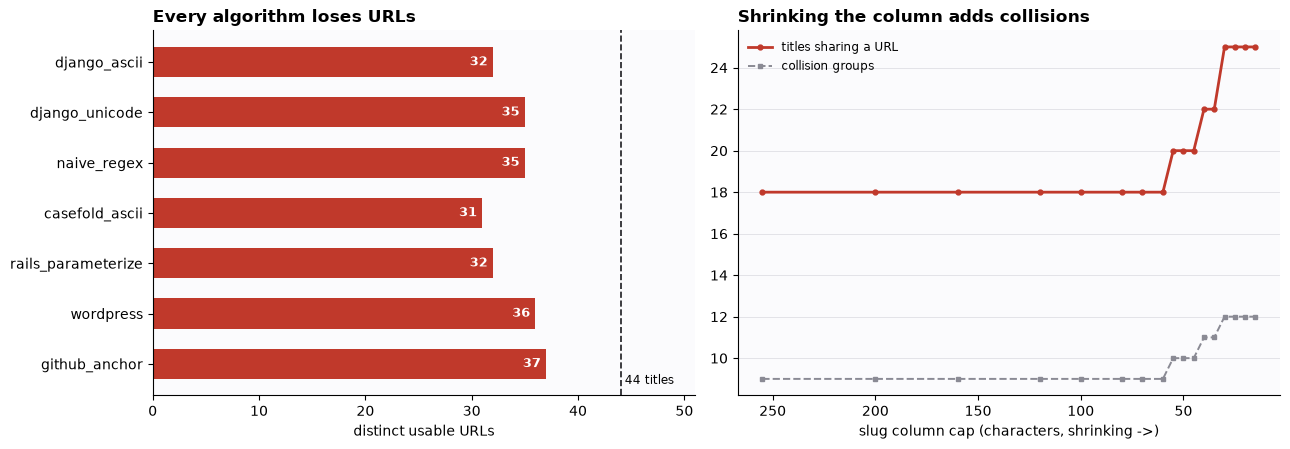

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

names = list(S.PROFILES)
n_titles = len(S.CORPUS)
distinct = [len({s for s in S.audit(S.CORPUS, x).slugs.values() if s}) for x in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
fig.patch.set_facecolor("white")

bars = ax1.barh(names, distinct, color="#c0392b", height=0.6)
for b, v in zip(bars, distinct):
    ax1.text(v - 0.5, b.get_y() + b.get_height() / 2, str(v), color="white",
             fontsize=9, fontweight="bold", ha="right", va="center")
ax1.axvline(n_titles, color="#1b1b1f", ls="--", lw=1.2)
ax1.text(n_titles + 0.4, len(names) - 0.6, f"{n_titles} titles", fontsize=8.5)
ax1.set_xlim(0, n_titles + 7)
ax1.invert_yaxis()
ax1.set_xlabel("distinct usable URLs")
ax1.set_title("Every algorithm loses URLs", loc="left", fontweight="bold")

caps = [255, 200, 160, 120, 100, 80, 70, 60, 55, 50, 45, 40, 35, 30, 25, 20, 15]
curve = S.truncation_curve(S.CORPUS, "django_ascii", caps)
ax2.plot([c for c, _, _, _ in curve], [h for _, _, h, _ in curve],
         color="#c0392b", lw=2, marker="o", ms=3.5, label="titles sharing a URL")
ax2.plot([c for c, _, _, _ in curve], [g for _, g, _, _ in curve],
         color="#8a8a94", lw=1.4, ls="--", marker="s", ms=3, label="collision groups")
ax2.invert_xaxis()
ax2.set_xlabel("slug column cap (characters, shrinking ->)")
ax2.set_title("Shrinking the column adds collisions", loc="left", fontweight="bold")
ax2.legend(frameon=False, fontsize=8.5, loc="upper left")
ax2.grid(axis="y", color="#e3e3e8", lw=0.7)
ax2.set_axisbelow(True)

for ax in (ax1, ax2):
    ax.set_facecolor("#fbfbfd")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig("slug_audit_nb.png", dpi=130, facecolor="white")
plt.show()

## Summary

| Mechanism | What it costs |
|---|---|
| NFKD + ASCII filter | letters with no decomposition (`ß ø æ Ł þ`) are deleted, not folded |
| `lower()` before the filter | decides whether `Straße` and `STRASSE` collide or split |
| no normalisation step | NFC and NFD of the same text get different URLs |
| punctuation removal | `C++` and `C#` are one URL; `Node.js` and `NodeJS` are one URL |
| ASCII-only profiles | every non-Latin title lands on the empty string together |
| length caps | narrowing the column creates collisions that did not exist |
| suffix de-duplication | the URL becomes a function of insertion order, not of the post |
| deletion | frees the bare slug for a stranger to inherit the inbound links |

None of these raise. None of them are invalid input. The slug function's return type has no room for any of
it, which is why the tool returns a **verdict** instead of a string.

## 10. Try your own

Paste your own titles below - a real export, a sitemap, the H1s from a docs site.

In [15]:
# my_titles = [
#     "Your first title",
#     "Your first title!",
#     "Título en español",
#     "北京オフィス",
# ]
#
# r = S.audit(my_titles, "django_ascii", cap=50)
# print(r.verdict.value, "-", r.reason)
# for f in r.findings:
#     print(f)
#
# for t, u in S.assign(my_titles, "django_ascii", cap=50).items():
#     print(f"{t:40} -> /{u}")

---

**[Slug collider](automation-suite/slug-collider)** - Day 144 of the
[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) portfolio.

Reproduce every number in the README: `python3 evidence.py`
Tests, including the collision detector cross-checked against an independent O(n^2) scan:
`python3 -m pytest test_slug.py -q`
The Streamlit version - paste titles, pick an algorithm, see the migration diff: `streamlit run app.py`